# Przygotowanie zbiorów CIFAR-BW i CIFAR-RGB

Notebook tworzy z części treningowej oryginalnego CIFAR-10 dwa sparowane warianty o rozdzielczości 32 x 32:

- **CIFAR-RGB** - oryginalne obrazy kolorowe,
- **CIFAR-BW** - te same obrazy przekonwertowane do skali szarości.

Każdy wariant zawiera pięć rozłącznych podzbiorów po 144 próbki na każdą z 10 klas. Każdy podzbiór jest następnie dzielony w sposób stratyfikowany na dane treningowe, walidacyjne i testowe.

Obrazek $32\times 32$, który chcemy zakodować jako macierz unitarną operatora kodującego go na komputerze kwantowym przy użyciu metody FRQI wymaga 16 MB dla complex32.

Obrazek kolorowy $32\times 32\times 3$, który chcemy zakodować jako macierz unitarną operatora kodującego go na komputerze kwantowym przy użyciu metody MCQI wymaga 256 MB dla complex32.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split

ds = load_dataset("uoft-cs/cifar10")
class_names = ds["train"].features["label"].names
print(ds)
print("Klasy:", class_names)

c:\Users\micha\OneDrive_PolSl\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})
Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


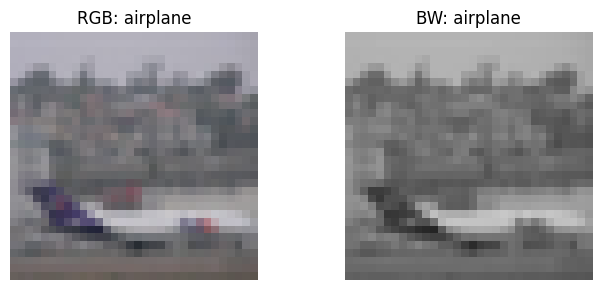

In [2]:
sample = ds["train"][0]
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(sample["img"].convert("RGB"))
axes[0].set_title(f"RGB: {class_names[sample['label']]}")
axes[1].imshow(sample["img"].convert("L"), cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"BW: {class_names[sample['label']]}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
seed = 71  # Kierunkowy na Wrocław :)
n_samples_per_class = 144
n_subsets = 5
n_classes = 10
resolution = (32, 32)
test_size = 0.20
val_size_of_train_val = 0.20


@dataclass
class DatasetSplit:
    X: np.ndarray
    y: np.ndarray


@dataclass
class DataBlock:
    train: DatasetSplit
    val: DatasetSplit
    test: DatasetSplit


@dataclass
class DataSet:
    subsets: list[DataBlock]
    info: dict

In [4]:
def select_disjoint_subset_indices(labels, *, seed, n_subsets, n_samples_per_class, n_classes):
    """Wybierz rozłączne, zbalansowane indeksy; wspólne dla BW i RGB."""
    labels = np.asarray(labels, dtype=np.int64)
    rng = np.random.default_rng(seed)
    required_per_class = n_subsets * n_samples_per_class
    selected = [[] for _ in range(n_subsets)]

    for cls in range(n_classes):
        class_indices = np.flatnonzero(labels == cls)
        if class_indices.size < required_per_class:
            raise ValueError(
                f"Klasa {cls} ma {class_indices.size} próbek, "
                f"a potrzeba co najmniej {required_per_class}."
            )

        shuffled = rng.permutation(class_indices)[:required_per_class]
        for subset_idx in range(n_subsets):
            start = subset_idx * n_samples_per_class
            stop = start + n_samples_per_class
            selected[subset_idx].extend(shuffled[start:stop])

    # Tasowanie usuwa grupowanie według klas, nie zmieniając składu podzbiorów.
    return [rng.permutation(np.asarray(indices, dtype=np.int64)) for indices in selected]


train_labels = np.asarray(ds["train"]["label"], dtype=np.int64)
subset_indices = select_disjoint_subset_indices(
    train_labels,
    seed=seed,
    n_subsets=n_subsets,
    n_samples_per_class=n_samples_per_class,
    n_classes=n_classes,
)

assert len(np.unique(np.concatenate(subset_indices))) == n_subsets * n_classes * n_samples_per_class
print(f"Wybrano {n_subsets} rozłącznych podzbiorów po {len(subset_indices[0])} obrazów.")

Wybrano 5 rozłącznych podzbiorów po 1440 obrazów.


In [5]:
def image_to_array(image, color_mode):
    if image.size != resolution:
        raise ValueError(f"Oczekiwano obrazu {resolution}, otrzymano {image.size}.")
    pil_mode = "RGB" if color_mode == "RGB" else "L"
    return np.asarray(image.convert(pil_mode), dtype=np.uint8)


def make_data_block(X, y, *, random_state):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_size_of_train_val,
        random_state=random_state,
        stratify=y_train_val,
    )
    return DataBlock(
        train=DatasetSplit(X_train, y_train),
        val=DatasetSplit(X_val, y_val),
        test=DatasetSplit(X_test, y_test),
    )


def build_cifar_variant(color_mode):
    if color_mode not in {"BW", "RGB"}:
        raise ValueError("color_mode musi mieć wartość 'BW' albo 'RGB'.")

    blocks = []
    for subset_idx, indices in enumerate(subset_indices):
        samples = ds["train"].select(indices.tolist())
        X = np.stack([image_to_array(image, color_mode) for image in samples["img"]])
        y = np.asarray(samples["label"], dtype=np.int64)
        blocks.append(make_data_block(X, y, random_state=seed))

    info = {
        "name": f"CIFAR-{color_mode}",
        "source": "uoft-cs/cifar10",
        "source_split": "train",
        "n_samples_per_class": n_samples_per_class,
        "n_subsets": n_subsets,
        "n_classes": n_classes,
        "class_names": class_names,
        "resolution": resolution,
        "color_mode": color_mode,
        "channels": 3 if color_mode == "RGB" else 1,
        "dtype": "uint8",
        "seed": seed,
        "split_ratios": {"train": 0.64, "val": 0.16, "test": 0.20},
    }
    return DataSet(subsets=blocks, info=info)

In [6]:
cifar_bw = build_cifar_variant("BW")
cifar_rgb = build_cifar_variant("RGB")

print(cifar_bw.info)
print(cifar_rgb.info)

{'name': 'CIFAR-BW', 'source': 'uoft-cs/cifar10', 'source_split': 'train', 'n_samples_per_class': 144, 'n_subsets': 5, 'n_classes': 10, 'class_names': ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'], 'resolution': (32, 32), 'color_mode': 'BW', 'channels': 1, 'dtype': 'uint8', 'seed': 71, 'split_ratios': {'train': 0.64, 'val': 0.16, 'test': 0.2}}
{'name': 'CIFAR-RGB', 'source': 'uoft-cs/cifar10', 'source_split': 'train', 'n_samples_per_class': 144, 'n_subsets': 5, 'n_classes': 10, 'class_names': ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'], 'resolution': (32, 32), 'color_mode': 'RGB', 'channels': 3, 'dtype': 'uint8', 'seed': 71, 'split_ratios': {'train': 0.64, 'val': 0.16, 'test': 0.2}}


In [7]:
def validate_dataset(dataset, expected_image_shape):
    assert len(dataset.subsets) == n_subsets
    expected_total = n_samples_per_class * n_classes

    for subset_idx, block in enumerate(dataset.subsets):
        splits = (block.train, block.val, block.test)
        X_all = np.concatenate([split_.X for split_ in splits])
        y_all = np.concatenate([split_.y for split_ in splits])

        assert len(y_all) == expected_total
        assert X_all.shape[1:] == expected_image_shape
        assert X_all.dtype == np.uint8
        assert np.array_equal(np.bincount(y_all, minlength=n_classes), np.full(n_classes, n_samples_per_class))
        for split_ in splits:
            assert set(np.unique(split_.y)) == set(range(n_classes))

        sizes = tuple(len(split_.y) for split_ in splits)
        print(f"{dataset.info['name']} subset {subset_idx}: train/val/test = {sizes}")


validate_dataset(cifar_bw, (32, 32))
validate_dataset(cifar_rgb, (32, 32, 3))

CIFAR-BW subset 0: train/val/test = (921, 231, 288)
CIFAR-BW subset 1: train/val/test = (921, 231, 288)
CIFAR-BW subset 2: train/val/test = (921, 231, 288)
CIFAR-BW subset 3: train/val/test = (921, 231, 288)
CIFAR-BW subset 4: train/val/test = (921, 231, 288)
CIFAR-RGB subset 0: train/val/test = (921, 231, 288)
CIFAR-RGB subset 1: train/val/test = (921, 231, 288)
CIFAR-RGB subset 2: train/val/test = (921, 231, 288)
CIFAR-RGB subset 3: train/val/test = (921, 231, 288)
CIFAR-RGB subset 4: train/val/test = (921, 231, 288)


In [8]:
output_dir = Path(".")
bw_path = output_dir / f".CIFAR-BW_{n_subsets}_subsets_train_val_test_{resolution[0]}x{resolution[1]}.joblib"
rgb_path = output_dir / f".CIFAR-RGB_{n_subsets}_subsets_train_val_test_{resolution[0]}x{resolution[1]}.joblib"

joblib.dump(cifar_bw, bw_path)
joblib.dump(cifar_rgb, rgb_path)

print(f"Zapisano: {bw_path.resolve()}")
print(f"Zapisano: {rgb_path.resolve()}")

Zapisano: C:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\experiments\QNN_integration\datasets\CIFAR-10\.CIFAR-BW_5_subsets_train_val_test_32x32.joblib
Zapisano: C:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\experiments\QNN_integration\datasets\CIFAR-10\.CIFAR-RGB_5_subsets_train_val_test_32x32.joblib


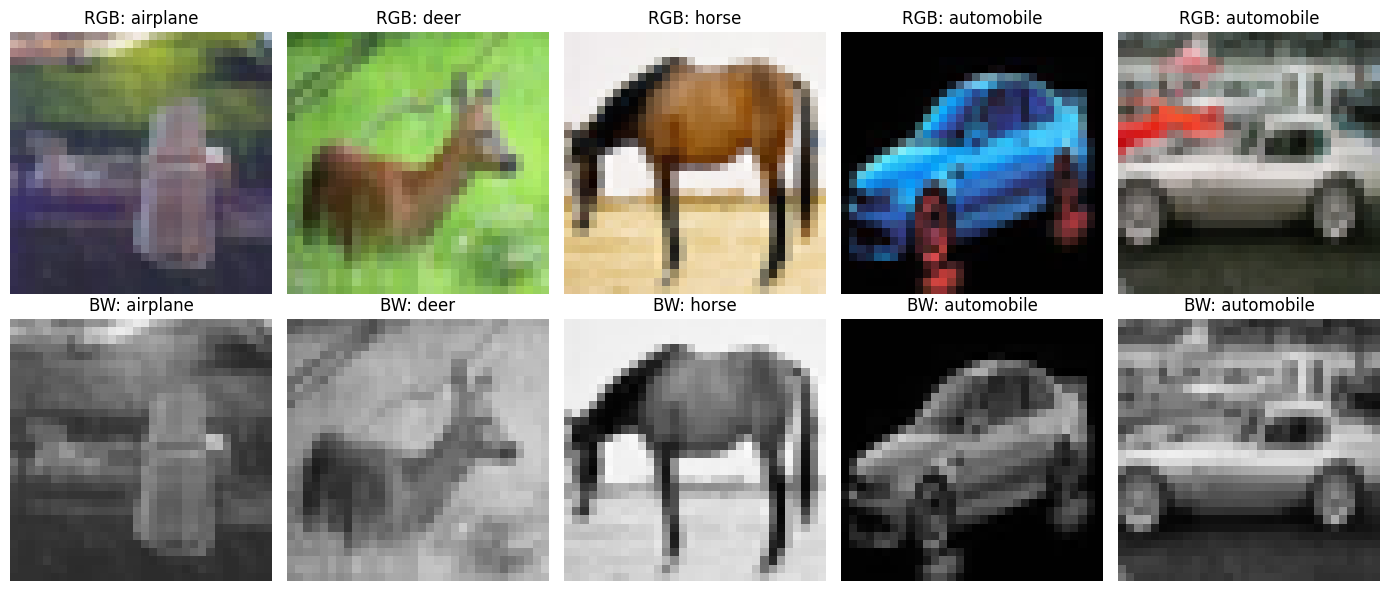

In [9]:
loaded_bw = joblib.load(bw_path)
loaded_rgb = joblib.load(rgb_path)

rng = np.random.default_rng(seed)
indices = rng.choice(len(loaded_rgb.subsets[0].train.X), size=5, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for column, index in enumerate(indices):
    label = loaded_rgb.subsets[0].train.y[index]
    axes[0, column].imshow(loaded_rgb.subsets[0].train.X[index])
    axes[0, column].set_title(f"RGB: {class_names[label]}")
    axes[1, column].imshow(loaded_bw.subsets[0].train.X[index], cmap="gray", vmin=0, vmax=255)
    axes[1, column].set_title(f"BW: {class_names[label]}")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()